# Florence cutout manning's N ensemble run.

## Configure
Configuration for individual users/machines.

In [1]:
# Configuration
import pathlib

# resource
n_cores = 7

# inputs
model_dir = pathlib.Path('/glade/u/home/jamesmcc/WRF_Hydro/wrf_hydro_nwm_public/trunk/NDHMS')
domain_dir = pathlib.Path('/glade/work/jamesmcc/domains/private/florence_933020089')
configuration = 'dart_nwm_channel-only'

# outputs
scratch_dir = pathlib.Path('/glade/scratch/jamesmcc')
experiment_dir = scratch_dir / 'florence_cutout_mannings_ensemble_run'
ens_routelink_dir = experiment_dir / 'ensemble_routelink_files'
compile_dir = experiment_dir / 'compile'
sim_dir = experiment_dir / 'simulation'
ens_dir = experiment_dir / 'ensemble'
chrtout_collected_gages_file = ens_dir / 'chrtout_collected_gages.nc'

## Simulation object

In [2]:
import wrfhydropy
import os

/glade/p/cisl/nwc/jamesmcc/anaconda3/lib/python3.7/site-packages/dask/config.py:168: YAMLLoadWarning: calling yaml.load() without Loader=... is deprecated, as the default Loader is unsafe. Please read https://msg.pyyaml.org/load for full details.
  data = yaml.load(f.read()) or {}
/glade/p/cisl/nwc/jamesmcc/anaconda3/lib/python3.7/site-packages/distributed/config.py:20: YAMLLoadWarning: calling yaml.load() without Loader=... is deprecated, as the default Loader is unsafe. Please read https://msg.pyyaml.org/load for full details.
  defaults = yaml.load(f)


Check the loaded modules... 

In [3]:
%%bash
module list


Currently Loaded Modules:
  1) intel/17.0.1      3) netcdf/4.6.1
  2) impi/2017.1.132   4) ncarcompilers/0.4.1

 



Check the repository state before doing this.

In [4]:
%%bash
cd ~/WRF_Hydro/wrf_hydro_nwm_public && git branch

  groundwater_rf
  master
  orchestrator
  test_chy_mod_fix
  test_exe_cmd
* v5.1.0


In [5]:
if not (compile_dir / 'WrfHydroModel.pkl').exists():
    model = wrfhydropy.Model(
        source_dir = model_dir, 
        model_config = configuration,
        hydro_namelist_config_file=domain_dir / 'hydro_namelists.json',
        hrldas_namelist_config_file=domain_dir / 'hrldas_namelists.json',
        compile_options={'WRF_HYDRO_NUDGING':0},
        compiler='ifort'
    )
    model.compile(compile_dir)
else:
    import pickle
    model = pickle.load(open(compile_dir / 'WrfHydroModel.pkl', 'rb'))

In [6]:
domain = wrfhydropy.Domain(
    domain_top_dir=domain_dir,
    domain_config=configuration
)

In [7]:
import datetime
model_start_time = datetime.datetime(2018, 8, 1, 0)
model_end_time = datetime.datetime(2018, 8, 5, 0)
job = wrfhydropy.Job(
    job_id = 'flo_cut_sim', 
    model_start_time=model_start_time,
    model_end_time=model_end_time,
    exe_cmd = 'mpirun -np 1 ./wrf_hydro.exe', 
    restart_freq_hr=-99999,
    output_freq_hr=1
)

In [8]:
sim = wrfhydropy.Simulation()

In [9]:
sim.add(domain)
sim.add(model)
sim.add(job)

/gpfs/u/home/jamesmcc/WRF_Hydro/wrf_hydro_py/wrfhydropy/core/simulation.py:232: UserWarning: Model minor versions v5.1.0-beta2
 do not match domain minor versions v5.1.0-alpha3
  domain.compatible_version)


Composing and running the simulation is not necessary for the ensemble, but it is informative.

In [10]:
if not sim_dir.exists():
    os.mkdir(sim_dir)
    os.chdir(sim_dir)
    sim.compose()
    sim.run()

## Generate an ensemble of routelink files

In [11]:
import pywrfhydro
import xarray as xa

In [12]:
routelink_file = sim_dir / sim.base_hydro_namelist['hydro_nlist']['route_link_f']

In [13]:
routelink = xa.open_dataset(routelink_file)
mannings_n = routelink['n']

In [14]:
if not ens_routelink_dir.exists():
    ens_routelink_dir.mkdir(parents=True)
    delta_mults = [.5, .75, 1.0, 1.25, 1.5]
    for delta_mult in delta_mults:
        out_file = ens_routelink_dir / ('Route_Link_edit_' + str(delta_mult) + '.nc')
        values_dict = { 'n' : mannings_n * delta_mult }
        result = pywrfhydro.routelink_edit(values_df=values_dict, in_file=routelink_file, out_file=out_file)
sorted(ens_routelink_dir.glob('Route_Link_edit*'))

[PosixPath('/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble_routelink_files/Route_Link_edit_0.5.nc'),
 PosixPath('/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble_routelink_files/Route_Link_edit_0.75.nc'),
 PosixPath('/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble_routelink_files/Route_Link_edit_1.0.nc'),
 PosixPath('/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble_routelink_files/Route_Link_edit_1.25.nc'),
 PosixPath('/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble_routelink_files/Route_Link_edit_1.5.nc')]

## Ensemble object

In [15]:
ens = wrfhydropy.EnsembleSimulation()

In [16]:
ens.add(sim)

In [17]:
job.model_end_time = datetime.datetime(2018, 11, 1, 0)
ens.add(job) # if the job is not present, member diffs are messed up!

In [18]:
ens.replicate_member(5)

In [19]:
routelink_files = [str(ff) for ff in sorted(ens_routelink_dir.glob("Route_Link*.nc"))]
print(routelink_files)

['/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble_routelink_files/Route_Link_edit_0.5.nc', '/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble_routelink_files/Route_Link_edit_0.75.nc', '/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble_routelink_files/Route_Link_edit_1.0.nc', '/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble_routelink_files/Route_Link_edit_1.25.nc', '/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble_routelink_files/Route_Link_edit_1.5.nc']


In [20]:
ens.set_member_diffs(
    att_tuple=('base_hydro_namelist', 'hydro_nlist', 'route_link_f'),
    values = routelink_files
)

In [21]:
ens.member_diffs

{('base_hydro_namelist',
  'hydro_nlist',
  'route_link_f'): ['/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble_routelink_files/Route_Link_edit_0.5.nc', '/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble_routelink_files/Route_Link_edit_0.75.nc', '/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble_routelink_files/Route_Link_edit_1.0.nc', '/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble_routelink_files/Route_Link_edit_1.25.nc', '/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble_routelink_files/Route_Link_edit_1.5.nc'],
 'number': ['000', '001', '002', '003', '004'],
 'run_dir': ['member_000',
  'member_001',
  'member_002',
  'member_003',
  'member_004']}

In [22]:
if not ens_dir.exists():
    os.mkdir(ens_dir)
    os.chdir(ens_dir)
    ens.compose()
    ens.run(n_concurrent=n_cores)

## Collect the data

In [23]:
chrtouts_files = sorted(ens_dir.glob('member*/*.CHRTOUT_DOMAIN1'))
chrtouts_files[1:5]

[PosixPath('/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble/member_000/201808010200.CHRTOUT_DOMAIN1'),
 PosixPath('/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble/member_000/201808010300.CHRTOUT_DOMAIN1'),
 PosixPath('/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble/member_000/201808010400.CHRTOUT_DOMAIN1'),
 PosixPath('/glade/scratch/jamesmcc/florence_cutout_mannings_ensemble_run/ensemble/member_000/201808010500.CHRTOUT_DOMAIN1')]

In [24]:
import xarray as xr
import dask
import numpy as np
import multiprocessing.pool

In [25]:
if not chrtout_collected_gages_file.exists():
    def get_file_path(ds):
        var = next(var for var in ds)
        return ds.assign(
            member=int(pathlib.Path(ds[var].encoding['source']).parent.name.split('_')[1]),
            reference_time=None
        )
    
    the_pool=multiprocessing.pool.Pool(n_cores*2) #scketch! but they dont use much cpu or memory. 
    with dask.config.set(scheduler='processes', pool=the_pool):
        chrtouts_ds = xr.open_mfdataset(
            chrtouts_files, 
            preprocess=get_file_path,
            concat_dim='time', 
            parallel=True
        )
    the_pool.close()
    
    rl_file = ens_dir / 'member_000/NWM/DOMAIN/Route_Link_fromVars.nc'
    rl = xr.open_dataset(rl_file)
    gages = rl[['gages', 'link']].to_dataframe()
    gages['gages'] = gages['gages'].str.decode("utf-8").str.strip()
    missing_gage = ''
    gages = gages.loc[gages['gages'] != missing_gage]
    link_gages = gages.loc[:,'link'].values
    
    keep_inds = np.where(chrtouts_ds['feature_id'].isin(link_gages))[0]
    chrtouts_gages = chrtouts_ds.isel(feature_id=keep_inds)
    chrtouts_gages.to_netcdf(chrtout_collected_gages_file)

## Plot at the gages

Realize the data

In [27]:
chrtouts_gages = xr.open_dataset(chrtout_collected_gages_file)
chrtouts_plot = chrtouts_gages.to_dataframe()
chrtouts_plot.reset_index(level=['feature_id'], inplace=True)
chrtouts_plot.reset_index(level=['time'], inplace=True)

In [28]:
chrtouts_plot.head()

,time,feature_id,reference_time,latitude,longitude,crs,order,elevation,streamflow,q_lateral,velocity,Head,member
0,2018-08-01 01:00:00,8777373,NaN,36.143345,-78.829269,b'',4,80.629997,1.331655,0.001087,0.433066,0.247177,0
1,2018-08-01 02:00:00,8777373,NaN,36.143345,-78.829269,b'',4,80.629997,1.331586,0.001093,0.433057,0.247169,0
2,2018-08-01 03:00:00,8777373,NaN,36.143345,-78.829269,b'',4,80.629997,1.331517,0.001099,0.433049,0.247162,0
3,2018-08-01 04:00:00,8777373,NaN,36.143345,-78.829269,b'',4,80.629997,1.331450,0.001105,0.433041,0.247154,0
4,2018-08-01 05:00:00,8777373,NaN,36.143345,-78.829269,b'',4,80.629997,1.331382,0.001112,0.433033,0.247147,0


/glade/p/cisl/nwc/jamesmcc/anaconda3/lib/python3.7/site-packages/bokeh/plotting/helpers.py:21: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated, and in 3.8 it will stop working
  from collections import Iterable, OrderedDict, Sequence
/glade/p/cisl/nwc/jamesmcc/anaconda3/lib/python3.7/site-packages/jinja2/utils.py:485: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated, and in 3.8 it will stop working
  from collections import MutableMapping
/glade/p/cisl/nwc/jamesmcc/anaconda3/lib/python3.7/site-packages/nbconvert/exporters/exporter_locator.py:28: DeprecationWarning: `nbconvert.exporters.exporter_locator` is deprecated in favor of `nbconvert.exporters.base` since nbconvert 5.0.
  DeprecationWarning)


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
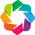

In [29]:
import holoviews as hv
from holoviews import opts
hv.extension('bokeh')

In [30]:
def location_plot(data, feature_id):
    data_loc = data.loc[data['feature_id'] == feature_id]
    ds = hv.Dataset(data_loc, ['time', 'member'], ['streamflow','velocity', 'Head'])
    return (
        ds.to(hv.Curve, 'time', 'streamflow').overlay('member') + 
        ds.to(hv.Curve, 'time', 'Head').overlay('member') + 
        ds.to(hv.Curve, 'time', 'velocity').overlay('member')
    ).cols(1)

In [31]:
the_features = chrtouts_plot['feature_id'].unique().tolist()
loc_dict = {(feature): location_plot(chrtouts_plot, feature) for feature in the_features}
kdims = [hv.Dimension(('feature_id', 'feature id'))]
holomap = hv.HoloMap(loc_dict, kdims=kdims)
holomap.opts(opts.Curve(width=900, height=200))

/glade/p/cisl/nwc/jamesmcc/anaconda3/lib/python3.7/site-packages/bokeh/core/property/container.py:102: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated, and in 3.8 it will stop working
  return (isinstance(value, (collections.Container, collections.Sized, collections.Iterable))


:HoloMap   [feature_id]
   :Layout
      .NdOverlay.I   :NdOverlay   [member]
         :Curve   [time]   (streamflow)
      .NdOverlay.II  :NdOverlay   [member]
         :Curve   [time]   (Head)
      .NdOverlay.III :NdOverlay   [member]
         :Curve   [time]   (velocity)